# Libraries

In [1]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize

from nltk.stem import WordNetLemmatizer

from textblob import TextBlob

import re

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Downloading NLTK resources

nltk.download('punkt', download_dir='C:/nltk_data')
nltk.download('stopwords', download_dir='C:/nltk_data')
nltk.download('wordnet', download_dir='C:/nltk_data')
nltk.download('omw-1.4', download_dir='C:/nltk_data')
nltk.download('punkt_tab',download_dir='C:/nltk_data' )
nltk.data.path.append('C:/nltk_data')

[nltk_data] Downloading package punkt to C:/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print(stopwords.words('english')[:10])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [4]:
# Importing Dataset

sent_original = pd.read_csv(r"C:\Users\DELL\Downloads\3) Sentiment dataset.csv")
sent_copied = sent_original
sent_copied.head(5)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [5]:
# Cleaning column names


sent_copied = sent_copied.loc[:, ~sent_copied.columns.str.contains('^Unnamed')]
print("Dataset loaded! Shape:", sent_copied.shape)
print ("Sample Text: \n", sent_copied['Text'].iloc[0])

Dataset loaded! Shape: (732, 13)
Sample Text: 
  Enjoying a beautiful day at the park!              


In [7]:
# Text Preprocessing


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '' , str(text).lower())
    
    
    tokens = word_tokenize(text)
    
    # Removing stopwords + lemmatize
    tokens =[lemmatizer.lemmatize(word) for word in tokens if word not in stop_words ]
    
    return " ".join(tokens)

sent_copied['Cleaned_Text'] = sent_copied['Text'].apply(preprocess_text)
print ("Text preprocessing completed!")

Text preprocessing completed!


In [8]:
# Sentiment Analysis with TextBlob

def get_sentimemt(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else: 
        return 'Neutral'
    
sent_copied['Predicted_Sentiment'] = sent_copied['Cleaned_Text'].apply(get_sentimemt)

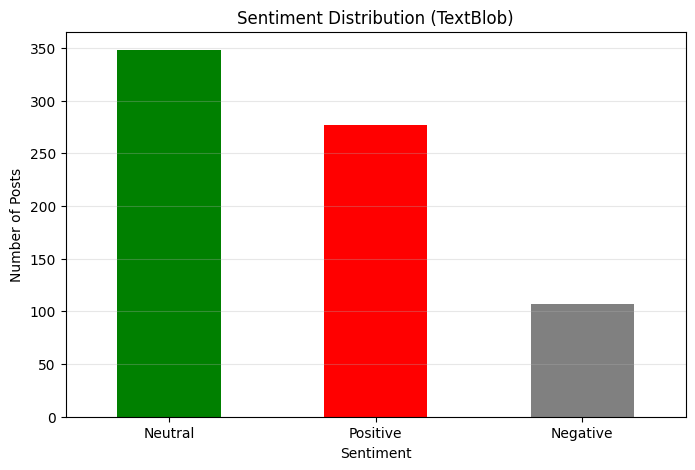

In [9]:
# Visualizing Sentiment Distribution


plt.figure(figsize=(8, 5))
sent_copied['Predicted_Sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [10]:
# Comparison with original labels


if 'Sentiment' in sent_copied.columns:
    print("\nOriginal Sentiment Distribution: \n", sent_copied['Sentiment'].value_counts().head(10))


Original Sentiment Distribution: 
 Sentiment
Positive        44
Joy             42
Excitement      32
Neutral         14
Contentment     14
Happy           14
Gratitude        9
Sad              9
Hopeful          9
Curiosity        8
Name: count, dtype: int64


In [15]:
# Word Clouds for Each Sentiment


def generate_wordcloud(texts, title):
    all_text = ' '.join(texts)
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap= 'viridis', max_words=100).generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()
    






Generating Word Clouds...


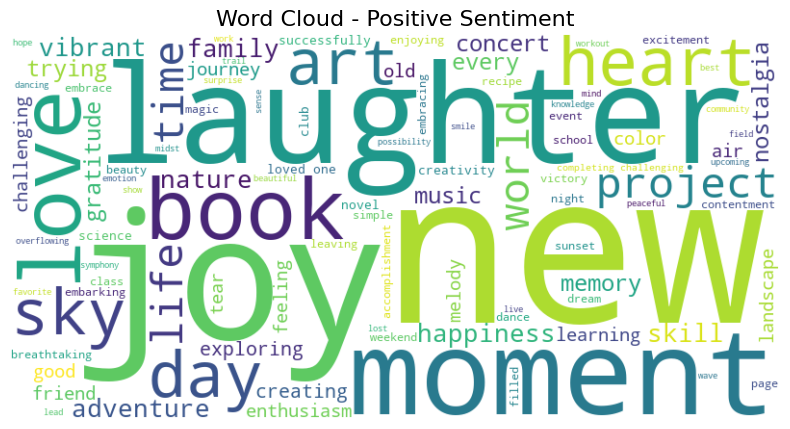

In [16]:
print("\nGenerating Word Clouds...")   


# Positive
generate_wordcloud(sent_copied[sent_copied['Predicted_Sentiment']== 'Positive']['Cleaned_Text'], 'Word Cloud - Positive Sentiment')

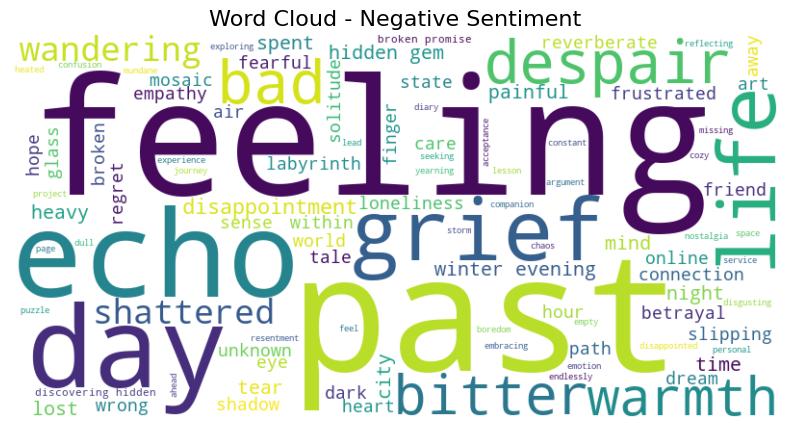

In [13]:
# Negative
generate_wordcloud(sent_copied[sent_copied['Predicted_Sentiment']== 'Negative']['Cleaned_Text'], 'Word Cloud - Negative Sentiment')




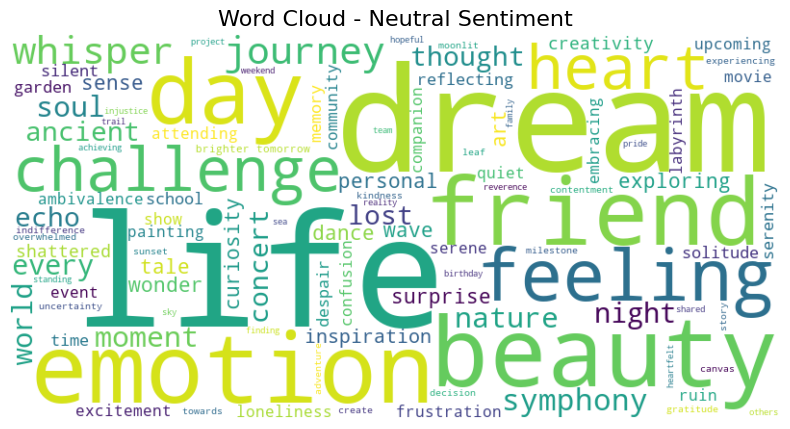

In [14]:
# Neutral
generate_wordcloud(sent_copied[sent_copied['Predicted_Sentiment']== 'Neutral']['Cleaned_Text'], 'Word Cloud - Neutral Sentiment')

In [17]:
#  In Summary



print("SENTIMENT ANALYSIS COMPLETE")
print("="*60)
print("• Positive posts :", len(sent_copied[sent_copied['Predicted_Sentiment'] == 'Positive']))
print("• Negative posts :", len(sent_copied[sent_copied['Predicted_Sentiment'] == 'Negative']))
print("• Neutral posts  :", len(sent_copied[sent_copied['Predicted_Sentiment'] == 'Neutral']))
print("• Most common positive words: beautiful, love, happy, excited...")
print("• Most common negative words: bad, hate, sad, disappointment...")


print("\nThe script also works great with the original 'Sentiment' column if you want to compare!")

SENTIMENT ANALYSIS COMPLETE
• Positive posts : 277
• Negative posts : 107
• Neutral posts  : 348
• Most common positive words: beautiful, love, happy, excited...
• Most common negative words: bad, hate, sad, disappointment...

The script also works great with the original 'Sentiment' column if you want to compare!
